# Setup & Import Libraries

In [6]:
# Install libraries
import os
import re
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patheffects as path_effects
import seaborn as sns
from PIL import Image
from matplotlib.ticker import FuncFormatter

print("Files in working directory:")
for f in os.listdir():
    print(f)

Files in working directory:
nimplex_GF_5_20_nodes.npy
.ipynb_checkpoints
NbCrVWZr Graph Database Analysis-Copy1.ipynb
nimplex_GF_5_20_neighbors.npy
NbCrVWZr_dataset_1.xlsx


In [7]:
# File paths
XLSX_PATH = "NbCrVWZr_dataset_1.xlsx"
NODES_NPY_PATH = "nimplex_GF_5_20_nodes.npy"
NEIGHBORS_NPY_PATH = "nimplex_GF_5_20_neighbors.npy"

# Load dataset
df = pd.read_excel(XLSX_PATH)
print(df.head())

# Load graph node and neighbor arrays
node_data = np.load(NODES_NPY_PATH)
neighbors_data = np.load(NEIGHBORS_NPY_PATH)

print(f"Number of nodes in node_data: {node_data.shape[0]}")
print(f"Node limit check (4x): {node_data.shape[0] * 4}")
print("AuraDB Free node limit: 200000")

def truncate_colormap(cmap, minval=0.2, maxval=1.0, n=100):
    return LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval:.2f},{maxval:.2f})",
        cmap(np.linspace(minval, maxval, n)))

       umap0     umap1    Nb    Cr     V    W    Zr  Pugh_Ratio_PRIOR  \
0  11.830237  1.206058  0.75  0.05  0.10  0.0  0.10          3.886076   
1  11.378913  0.727617  0.75  0.05  0.15  0.0  0.05          3.940171   
2  11.947575  0.945526  0.75  0.10  0.05  0.0  0.10          3.619236   
3  11.669504  0.514054  0.75  0.10  0.10  0.0  0.05          3.666667   
4  11.693570  0.183822  0.75  0.15  0.05  0.0  0.05          3.426065   

   YS 1000C PRIOR  1000 Min Creep NH [1/s]  ...  \
0      187.693810             4.811600e-11  ...   
1      185.390681             2.755514e-11  ...   
2      251.917073             3.182097e-11  ...   
3      248.762842             1.955642e-11  ...   
4      319.151219             1.458918e-11  ...   

   EQ 1023K MAX BCC Boolean (BCC fraction ≥ 0.999)  \
0                                               No   
1                                               No   
2                                               No   
3                                     

# UMAPs of Pure Elements - No Constraint

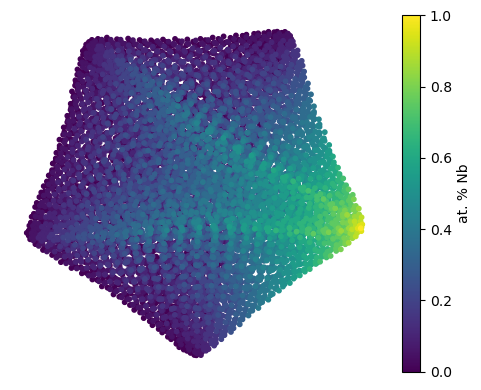

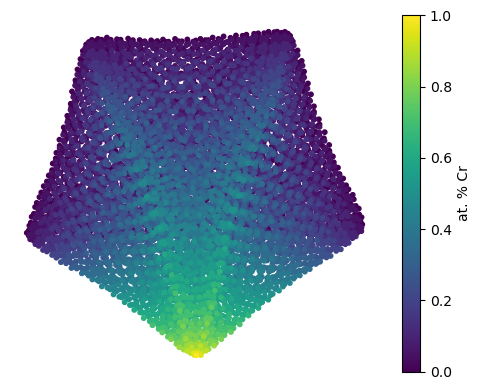

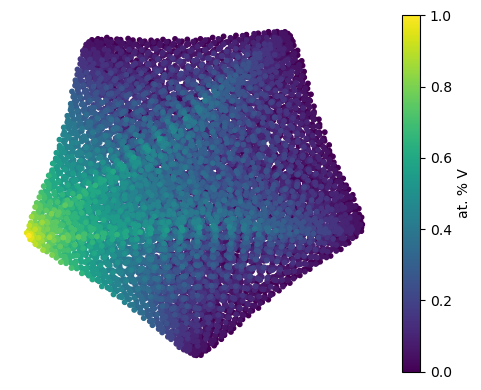

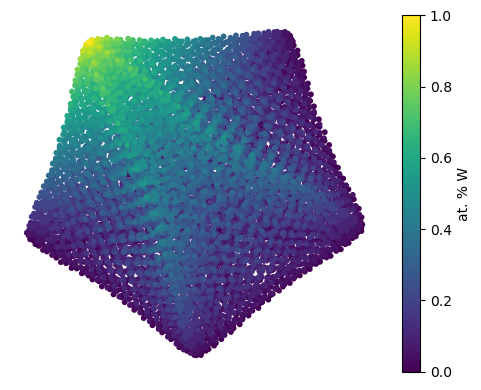

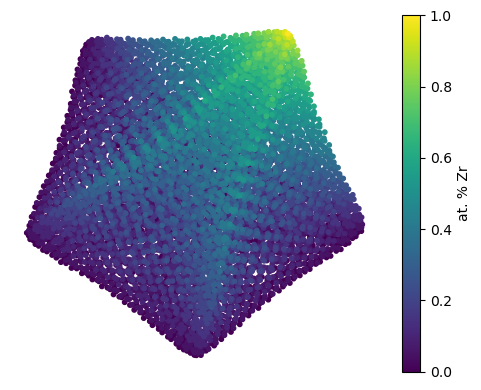

In [9]:
# Show the UMAP Vertices w/ respect to each pure element

# Input the elements
elements = ['Nb', 'Cr', 'V', 'W', 'Zr']
for el in elements:
    fig, ax = plt.subplots(figsize=(5, 4))
    df_sorted = df.sort_values(by=el)
    sc = ax.scatter(df_sorted["umap0"], df_sorted["umap1"], c=df_sorted[el], s=10)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(f"at. % {el}")

    ax.axis("off")
    plt.tight_layout()
    plt.show()

# UMAPs of Scheil Solidification Range

This code block originally filtered solidification range calculated from the solidus and liquidus temperatures and plotted the property density. These values come from Thermo-Calc so instead in the NbCrVWZr_dataset we have provided a boolean column to denote if the solidification range was below ("yes") or above ("no") 50 K. Density also comes from Thermo-Calc data so we will show how to plot Yield Strength evaluated at 1000C.

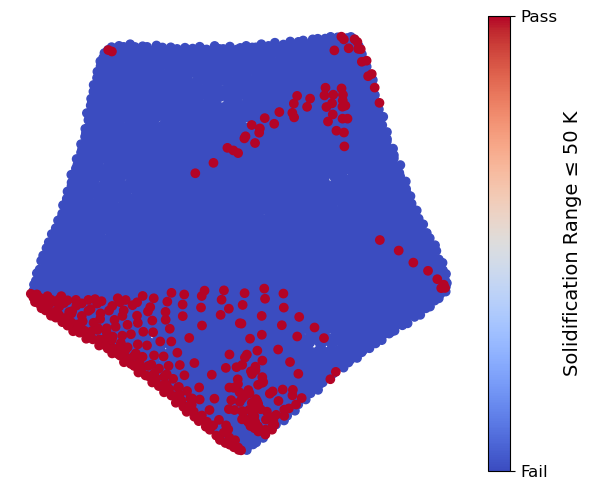

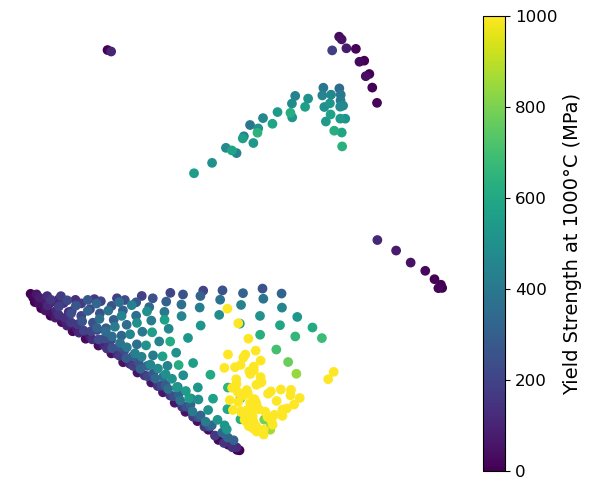

Saved: umap_before_filtering.png
Saved: umap_after_filtering.png
Ratio remaining after solidification-range filter: 0.0332


In [10]:
solid_col = "Solidification Range (K) Boolean (Solidification Range ≤ 50)"
ys_col = "YS 1000C PRIOR"

# Normalize the solidification criterion column ("Yes"/"No") for consistent filtering
df[solid_col] = df[solid_col].astype(str).str.strip()

# Sort for consistent plotting order
df_sorted = df.sort_values(by=solid_col)

# Filter to compositions that satisfy the solidification range criterion
filtered_df = df[df[solid_col] == "Yes"].copy()
filtered_df_sorted = filtered_df.sort_values(by=ys_col)

# UMAP before filtering, colored by whether the solidification criterion is satisfied
fig1, ax1 = plt.subplots(figsize=(6, 5))
sc1 = ax1.scatter(df_sorted["umap0"], df_sorted["umap1"], c=(df_sorted[solid_col] == "Yes"), cmap="coolwarm")
ax1.axis("off")

cbar1 = fig1.colorbar(sc1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_ticks([0, 1])
cbar1.set_ticklabels(["Fail", "Pass"])
cbar1.set_label("Solidification Range ≤ 50 K", fontsize=14)
cbar1.ax.tick_params(labelsize=12)

fig1.tight_layout()
fig1.savefig("umap_before_filtering.png", dpi=800, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()

# UMAP after filtering, colored by yield strength at 1000°C
fig2, ax2 = plt.subplots(figsize=(6, 5))
sc2 = ax2.scatter(filtered_df_sorted["umap0"], filtered_df_sorted["umap1"], c=filtered_df_sorted[ys_col], cmap="viridis", vmin=0, vmax=1000)
ax2.axis("off")

cbar2 = fig2.colorbar(sc2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label("Yield Strength at 1000°C (MPa)", fontsize=14)
cbar2.ax.tick_params(labelsize=12)

fig2.tight_layout()
fig2.savefig("umap_after_filtering.png", dpi=800, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()

print("Saved: umap_before_filtering.png")
print("Saved: umap_after_filtering.png")
print(f"Ratio remaining after solidification-range filter: {len(filtered_df) / len(df):.4f}")

# UMAPs of Eq BCC Filtering 

This code block originally filtered Equilibrium BCC phase fraction and plotted the property density. BCC phase fractions come from Thermo-Calc so instead, in the NbCrVWZr_dataset, we have provided a boolean column to denote if the phase fraction was above ("yes") or below ("no") 0.999. Density also comes from Thermo-Calc data so we will show how to plot Yield Strength evaluated at 1000C.

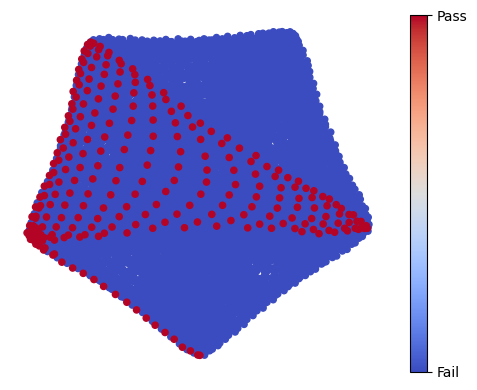

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /EQ_523K_MAX_BCC_Boolean_BCC_fraction_ge_0.999_B4_Filter2.png


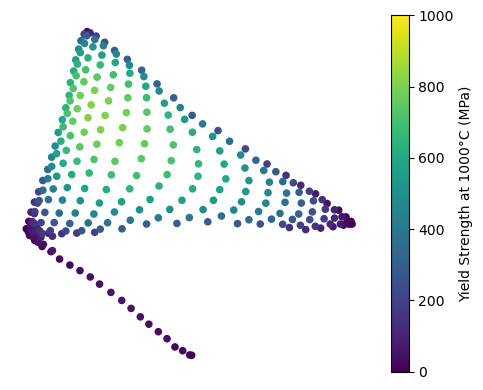

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /EQ_523K_MAX_BCC_Boolean_BCC_fraction_ge_0.999_After_Filter2.png


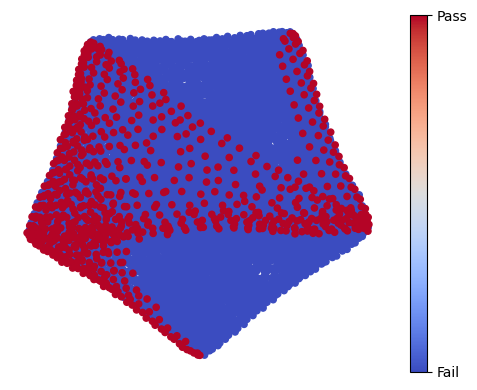

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /EQ_1273K_MAX_BCC_Boolean_BCC_fraction_ge_0.999_B4_Filter2.png


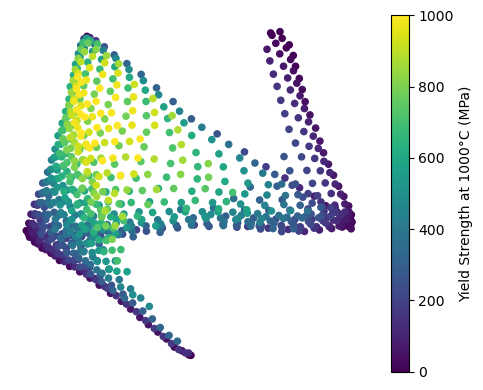

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /EQ_1273K_MAX_BCC_Boolean_BCC_fraction_ge_0.999_After_Filter2.png


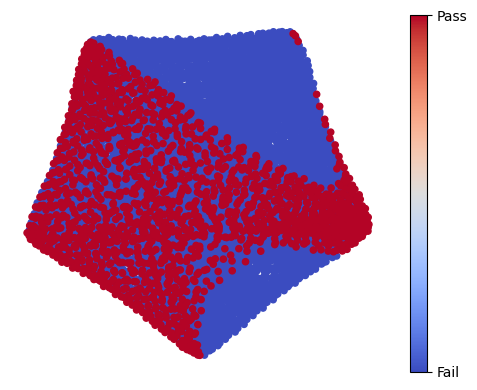

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /EQ_2023K_MAX_BCC_Boolean_BCC_fraction_ge_0.999_B4_Filter2.png


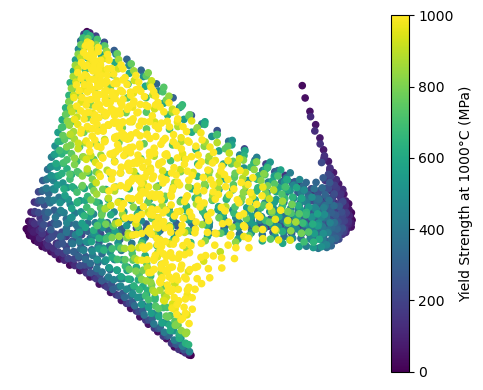

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /EQ_2023K_MAX_BCC_Boolean_BCC_fraction_ge_0.999_After_Filter2.png


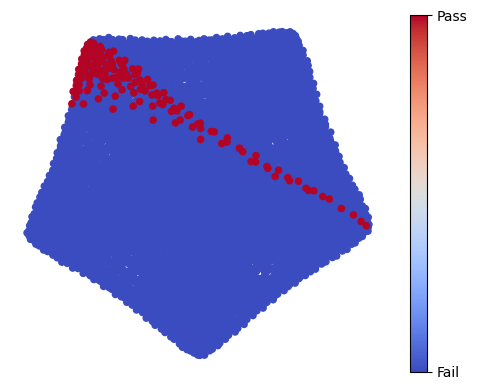

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /EQ_2773K_MAX_BCC_Boolean_BCC_fraction_ge_0.999_B4_Filter2.png


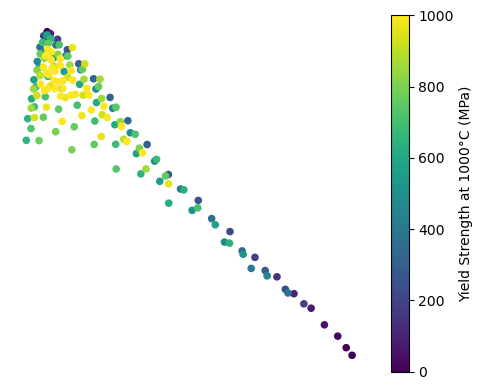

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /EQ_2773K_MAX_BCC_Boolean_BCC_fraction_ge_0.999_After_Filter2.png


In [11]:
bcc_boolean_cols = [
    "EQ 523K MAX BCC Boolean (BCC fraction ≥ 0.999)",
    "EQ 1273K MAX BCC Boolean (BCC fraction ≥ 0.999)",
    "EQ 2023K MAX BCC Boolean (BCC fraction ≥ 0.999)",
    "EQ 2773K MAX BCC Boolean (BCC fraction ≥ 0.999)"]

ys_col = "YS 1000C PRIOR"
save_dir = os.getcwd()
os.makedirs(save_dir, exist_ok=True)

# Normalize BCC boolean columns ("Yes"/"No") for consistent filtering
for col in bcc_boolean_cols:
    df[col] = df[col].astype(str).str.strip()

# Generate UMAPs before and after applying each BCC stability criterion
for col in bcc_boolean_cols:
    sanitized = col.replace(" ", "_").replace("(", "").replace(")", "").replace("≥", "ge")

    # UMAP before filtering, colored by whether the BCC criterion is satisfied
    fig, ax = plt.subplots(figsize=(5, 4))
    df_sorted = df.sort_values(by=col)
    sc = ax.scatter(df_sorted["umap0"], df_sorted["umap1"], c=(df_sorted[col] == "Yes"), cmap="coolwarm", s=20)
    ax.axis("off")

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Fail", "Pass"])

    fig.tight_layout()
    out_path = os.path.join(save_dir, f"{sanitized}_B4_Filter2.png")
    fig.savefig(out_path, dpi=800, transparent=True)
    plt.show()
    plt.close(fig)
    print(f"Saved: {out_path}")

    # Filter to compositions that satisfy the BCC criterion and plot yield strength
    filtered_df = df[df[col] == "Yes"].copy()
    filtered_df[ys_col] = pd.to_numeric(filtered_df[ys_col], errors="coerce")
    filtered_df = filtered_df.dropna(subset=[ys_col])
    filtered_df_sorted = filtered_df.sort_values(by=ys_col)

    fig, ax = plt.subplots(figsize=(5, 4))
    sc = ax.scatter(filtered_df_sorted["umap0"], filtered_df_sorted["umap1"], c=filtered_df_sorted[ys_col], cmap="viridis", s=20, vmin=0, vmax=1000)
    ax.axis("off")

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Yield Strength at 1000°C (MPa)")

    fig.tight_layout()
    out_path = os.path.join(save_dir, f"{sanitized}_After_Filter2.png")
    fig.savefig(out_path, dpi=800, transparent=True)
    plt.show()
    plt.close(fig)
    print(f"Saved: {out_path}")

# Temp vs Node Count Scatter Plot

This code block originally plotted the number of nodes that passed the equilibrium BCC filtering criteria of greater than 0.999 in the previous block. Since BCC values come from thermo-calc, boolean columns at each temperature have been added into the excel file (NbCrVWZr_dataset) to utilize.

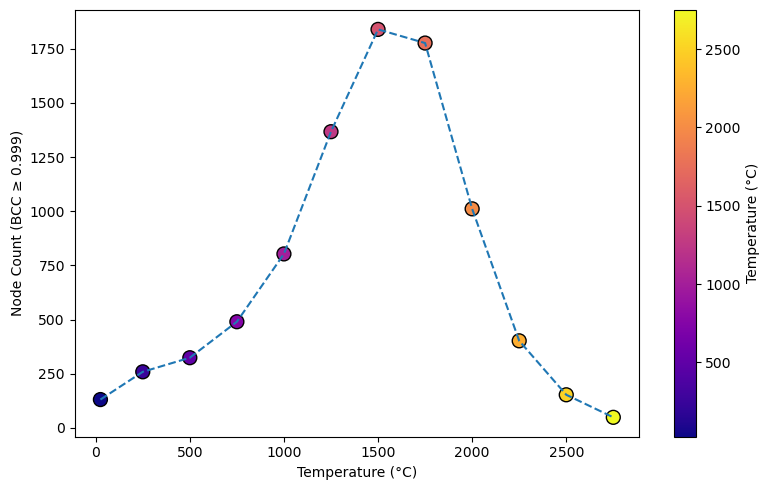

In [12]:
# Temperature list (K) corresponding to the BCC boolean columns
temps_K = np.array([298, 523, 773, 1023, 1273, 1523, 1773, 2023, 2273, 2523, 2773, 3023])
temps_C = temps_K - 273.15

# BCC stability boolean columns ("Yes" indicates BCC fraction ≥ 0.999)
bcc_bool_cols = ["EQ 298K MAX BCC Boolean (BCC fraction ≥ 0.999)",
                 "EQ 523K MAX BCC Boolean (BCC fraction ≥ 0.999)",
                 "EQ 773K MAX BCC Boolean (BCC fraction ≥ 0.999)",
                 "EQ 1023K MAX BCC Boolean (BCC fraction ≥ 0.999)",
                 "EQ 1273K MAX BCC Boolean (BCC fraction ≥ 0.999)",
                 "EQ 1523K MAX BCC Boolean (BCC fraction ≥ 0.999)",
                 "EQ 1773K MAX BCC Boolean (BCC fraction ≥ 0.999)",
                 "EQ 2023K MAX BCC Boolean (BCC fraction ≥ 0.999)",
                 "EQ 2273K MAX BCC Boolean (BCC fraction ≥ 0.999)",
                 "EQ 2523K MAX BCC Boolean (BCC fraction ≥ 0.999)",
                 "EQ 2773K MAX BCC Boolean (BCC fraction ≥ 0.999)",
                 "EQ 3023K MAX BCC Boolean (BCC fraction ≥ 0.999)"]

# Count the number of compositions satisfying the BCC criterion at each temperature
nodes = []
for col in bcc_bool_cols:
    yes_count = (df[col].astype(str).str.strip().str.lower() == "yes").sum()
    nodes.append(yes_count)

nodes = np.array(nodes)

# Scatter plot of node count versus temperature
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(temps_C, nodes, c=temps_C, cmap="plasma", s=100, edgecolor="black")
ax.plot(temps_C, nodes, linestyle="--")

fig.colorbar(sc, ax=ax, label="Temperature (°C)")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Node Count (BCC ≥ 0.999)")

plt.tight_layout()
plt.savefig("temp_vs_node_count_colormapped.png", dpi=300)
plt.show()

# UMAPs of Scheil BCC Filter

This code block originally filtered Scheil BCC phase fraction to remove anything less than 0.999. Scheil BCC phase fractions come from Thermo-Calc so instead, in the NbCrVWZr_dataset, we have provided a boolean column to denote if the phase fraction was above ("yes") or below ("no") 0.999.

All 'Node ID' values are unique.
Number of connected components: 10361
component_0: 118 nodes
component_1: 86 nodes
component_2: 38 nodes
component_3: 26 nodes


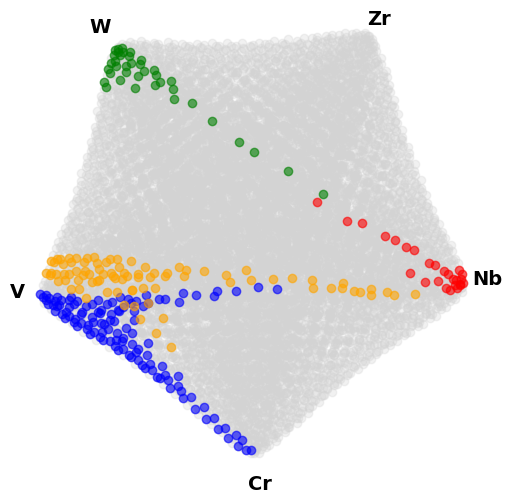

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /elemental_umap_components_color.png


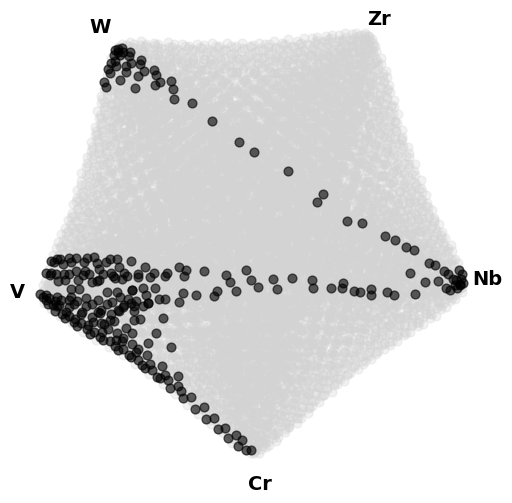

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /elemental_umap_components_black.png


In [13]:
scheil_col = "Scheil MAX BCC Boolean (BCC fraction ≥ 0.999)"
df[scheil_col] = df[scheil_col].astype(str).str.strip()

G = nx.Graph()
edges = [(node, neighbor) for node, neighbors in enumerate(neighbors_data) for neighbor in neighbors if neighbor != -1]
G.add_edges_from(edges)

elem_list = ["Nb", "Cr", "V", "W", "Zr"]
df["Node ID"] = None
for node_id, composition in enumerate(node_data):
    matching_row = df[(df[elem_list] == composition).all(axis=1)]
    if not matching_row.empty:
        df.at[matching_row.index[0], "Node ID"] = node_id

def check_unique_ids(dataframe):
    if dataframe["Node ID"].is_unique:
        print("\033[1mAll 'Node ID' values are unique.\033[0m")
    else:
        print("\033[1mDuplicate 'Node ID' values found.\033[0m")

check_unique_ids(df)

nodes_to_remove_edges = df[df[scheil_col] != "Yes"]["Node ID"].dropna().astype(int).tolist()
for node in nodes_to_remove_edges:
    G.remove_edges_from(list(G.edges(node)))

connected_components = list(nx.connected_components(G))
sorted_components = sorted(connected_components, key=len, reverse=True)
print(f"Number of connected components: {len(sorted_components)}")

for i, component in enumerate(sorted_components[:4]):
    print(f"component_{i}: {len(component)} nodes")

node_to_subgraph = {}
for subgraph_id, component in enumerate(sorted_components):
    for node_id in component:
        node_to_subgraph[node_id] = subgraph_id

df["Subgraph ID"] = df["Node ID"].map(node_to_subgraph)
component_masks = [(df["Subgraph ID"] == i) for i in range(4)]

colors = ["blue", "orange", "green", "red"]
labels = ["Component0", "Component1", "Component2", "Component3"]
elements = ["Nb", "Cr", "V", "W", "Zr"]

plt.figure(figsize=(6, 6))
plt.scatter(df["umap0"], df["umap1"], c="lightgray", alpha=0.3, label="All Compositions")

for i in range(4):
    plt.scatter(df.loc[component_masks[i], "umap0"], df.loc[component_masks[i], "umap1"], c=colors[i], alpha=0.6,
                label=f"{labels[i]} ({component_masks[i].sum()} nodes)")

plt.axis("off")
plt.text(13, 1, elements[0], fontsize=14, fontweight="bold")
plt.text(-4.5, 0.5, elements[2], fontsize=14, fontweight="bold")
plt.text(9, 10.5, elements[4], fontsize=14, fontweight="bold")
plt.text(-1.5, 10.2, elements[3], fontsize=14, fontweight="bold")
plt.text(4.5, -6.5, elements[1], fontsize=14, fontweight="bold")

out_path = os.path.join(os.getcwd(), "elemental_umap_components_color.png")
plt.savefig(out_path, dpi=800, transparent=True, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

colors_black = ["black", "black", "black", "black"]

plt.figure(figsize=(6, 6))
plt.scatter(df["umap0"], df["umap1"], c="lightgray", alpha=0.3, s=40)

for i in range(4):
    plt.scatter(df.loc[component_masks[i], "umap0"], df.loc[component_masks[i], "umap1"], c=colors_black[i], alpha=0.6, s=40,
                label=f"{labels[i]} ({component_masks[i].sum()} nodes)")

plt.axis("off")
plt.text(13, 1, elements[0], fontsize=14, fontweight="bold")
plt.text(-4.5, 0.5, elements[2], fontsize=14, fontweight="bold")
plt.text(9, 10.5, elements[4], fontsize=14, fontweight="bold")
plt.text(-1.5, 10.2, elements[3], fontsize=14, fontweight="bold")
plt.text(4.5, -6.5, elements[1], fontsize=14, fontweight="bold")

out_path = os.path.join(os.getcwd(), "elemental_umap_components_black.png")
plt.savefig(out_path, dpi=800, transparent=True, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

# KDE Plots of Scheil BCC Filter

/var/folders/v6/mn5ql6gn2wdd32g745lrzs840000gr/T/ipykernel_28018/1318317424.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(component_df[element], linewidth=4, color=element_colors.get(element, "black"))


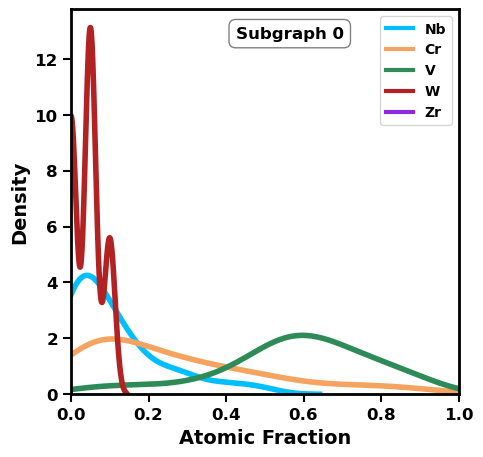

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /kde_elements_subgraph_0.png


/var/folders/v6/mn5ql6gn2wdd32g745lrzs840000gr/T/ipykernel_28018/1318317424.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(component_df[element], linewidth=4, color=element_colors.get(element, "black"))


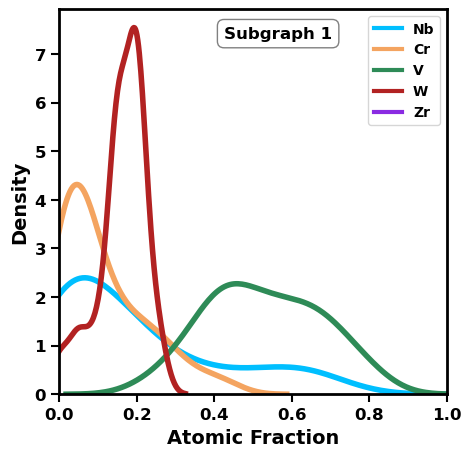

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /kde_elements_subgraph_1.png


/var/folders/v6/mn5ql6gn2wdd32g745lrzs840000gr/T/ipykernel_28018/1318317424.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(component_df[element], linewidth=4, color=element_colors.get(element, "black"))


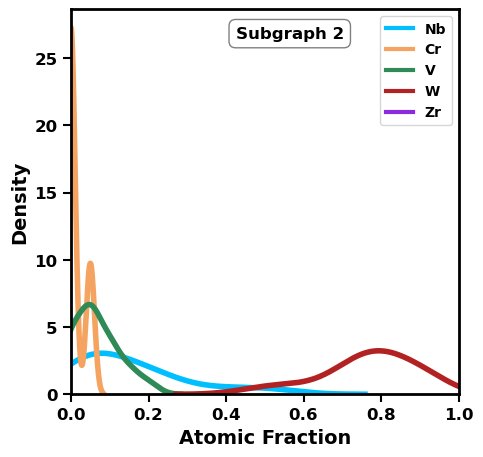

/var/folders/v6/mn5ql6gn2wdd32g745lrzs840000gr/T/ipykernel_28018/1318317424.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(component_df[element], linewidth=4, color=element_colors.get(element, "black"))


Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /kde_elements_subgraph_2.png


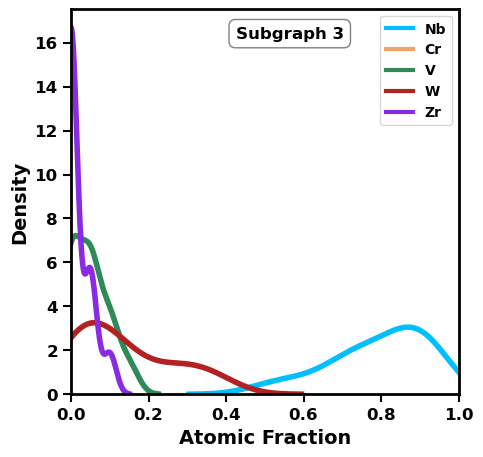

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /kde_elements_subgraph_3.png


In [14]:
elements = ["Nb", "Cr", "V", "W", "Zr"]
save_path = os.getcwd()

element_colors = {"Nb": "deepskyblue", "Cr": "sandybrown", "V": "seagreen", "W": "firebrick", "Zr": "blueviolet"}
legend_handles = [mlines.Line2D([], [], color=element_colors[e], linewidth=3, label=e) for e in elements]

# KDE plots of elemental distributions for Subgraphs 0–3
for i in range(4):
    component_df = df[df["Subgraph ID"] == i].copy()
    active_elements = [e for e in elements if e in component_df.columns]

    plt.figure(figsize=(5, 5))
    for element in active_elements:
        sns.kdeplot(component_df[element], linewidth=4, color=element_colors.get(element, "black"))

    plt.xlabel("Atomic Fraction", fontsize=14, fontweight="bold")
    plt.ylabel("Density", fontsize=14, fontweight="bold")
    plt.xlim(0, 1)
    plt.xticks(fontsize=12, fontweight="bold")
    plt.yticks(fontsize=12, fontweight="bold")
    plt.tick_params(width=1.5, length=6)

    plt.legend(handles=legend_handles, fontsize=12, title_fontproperties={"weight": "bold"}, prop={"weight": "bold"}, loc="upper right")

    plt.text(0.425, 0.925, f"Subgraph {i}", transform=plt.gca().transAxes, fontsize=12, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.4", facecolor="none", edgecolor="gray", linewidth=1))

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    file_name = f"kde_elements_subgraph_{i}.png"
    file_path = os.path.join(save_path, file_name)
    plt.savefig(file_path, bbox_inches="tight", pad_inches=0.1)
    plt.show()
    print(f"Saved: {file_path}")

# UMAP + KDE Plot Scheil BCC Properties

# Creep

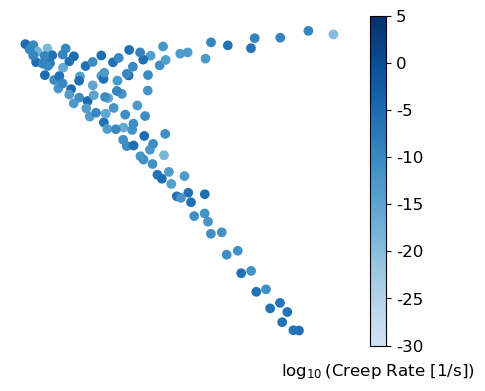

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_0_creep_fixedrange.png


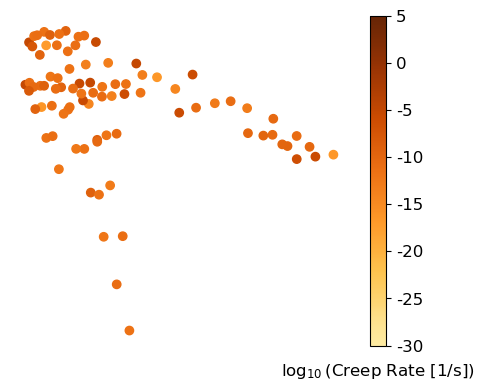

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_1_creep_fixedrange.png


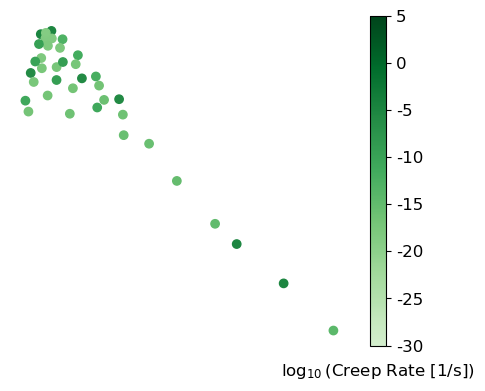

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_2_creep_fixedrange.png


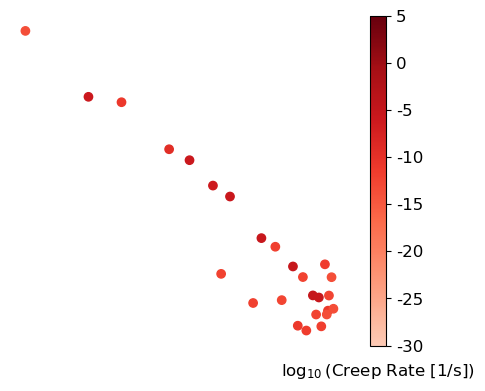

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_3_creep_fixedrange.png


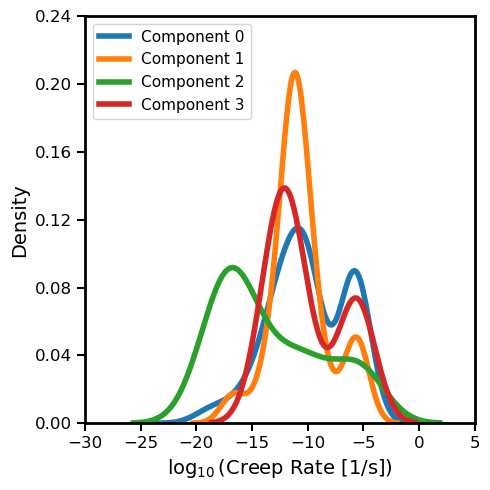

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /kde_creep_fixedrange.png


In [15]:
PROP_CREEP_RAW = "1000 Min Creep NH [1/s]"
N_COMPONENTS = 4
save_dir = os.getcwd()

# Hard-coded display ranges (log10 space)
CREEP_XMIN, CREEP_XMAX = -30.0, 5.0
CREEP_XTICKS = np.arange(CREEP_XMIN, CREEP_XMAX + 0.001, 5.0)

KDE_YMIN, KDE_YMAX = 0.00, 0.24
KDE_YTICKS = np.arange(KDE_YMIN, KDE_YMAX + 0.001, 0.04)

component_colormaps = {0: plt.cm.Blues, 1: plt.cm.YlOrBr, 2: plt.cm.Greens, 3: plt.cm.Reds}

# UMAP plots per component, colored by log10(creep rate)
for comp_idx, comp_nodes in enumerate(sorted_components[:N_COMPONENTS]):
    component_df = df[df["Node ID"].isin(list(comp_nodes))].copy()
    component_df[PROP_CREEP_RAW] = pd.to_numeric(component_df[PROP_CREEP_RAW], errors="coerce")
    component_df = component_df.dropna(subset=[PROP_CREEP_RAW])
    component_df = component_df[component_df[PROP_CREEP_RAW] > 0]

    if component_df.empty:
        print(f"No valid data for {PROP_CREEP_RAW} in Component {comp_idx}")
        continue

    component_df["log_creep"] = np.log10(component_df[PROP_CREEP_RAW])

    base_cmap = component_colormaps.get(comp_idx, plt.cm.viridis)
    cmap = truncate_colormap(base_cmap, minval=0.2, maxval=1.0)
    norm = Normalize(vmin=CREEP_XMIN, vmax=CREEP_XMAX)

    fig, ax = plt.subplots(figsize=(5, 4))
    sc = ax.scatter(component_df["umap0"], component_df["umap1"], c=component_df["log_creep"], cmap=cmap, norm=norm)

    cbar = fig.colorbar(sc, ax=ax, ticks=CREEP_XTICKS)
    cbar.ax.set_yticklabels([f"{int(t)}" for t in CREEP_XTICKS])
    cbar.set_label("")
    cbar.ax.text(0.5, -0.05, r"$\log_{10}$(Creep Rate [1/s])", transform=cbar.ax.transAxes,
                 ha="center", va="top", fontsize=12)
    cbar.ax.tick_params(labelsize=12)

    ax.axis("off")
    plt.tight_layout()
    plt.show()

    out_name = f"connected_component_{comp_idx}_creep_fixedrange.png"
    out_path = os.path.join(save_dir, out_name)
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")

# KDE plot across components in log10(creep rate)
plt.figure(figsize=(5, 5))

for comp_idx, comp_nodes in enumerate(sorted_components[:N_COMPONENTS]):
    component_df = df[df["Node ID"].isin(list(comp_nodes))].copy()
    component_df[PROP_CREEP_RAW] = pd.to_numeric(component_df[PROP_CREEP_RAW], errors="coerce")
    component_df = component_df.dropna(subset=[PROP_CREEP_RAW])
    component_df = component_df[component_df[PROP_CREEP_RAW] > 0]

    if component_df.empty:
        print(f"No valid data for {PROP_CREEP_RAW} in Component {comp_idx}")
        continue

    log_creep = np.log10(component_df[PROP_CREEP_RAW])
    sns.kdeplot(log_creep, linewidth=4, label=f"Component {comp_idx}")

plt.xlabel(r"$\log_{10}$(Creep Rate [1/s])", fontsize=14)
plt.ylabel("Density", fontsize=14)

ax = plt.gca()
ax.set_xlim((CREEP_XMIN, CREEP_XMAX))
ax.set_ylim((KDE_YMIN, KDE_YMAX))
ax.set_xticks(CREEP_XTICKS)
ax.set_yticks(KDE_YTICKS)
ax.set_yticklabels([f"{t:.2f}" for t in KDE_YTICKS])

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(width=1.5, length=6)
plt.legend(loc="upper left", fontsize=11)

for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()

out_name = "kde_creep_fixedrange.png"
out_path = os.path.join(save_dir, out_name)
plt.savefig(out_path, dpi=800, bbox_inches="tight", pad_inches=0.1)
plt.show()
print(f"Saved: {out_path}")

# Density

Density cannot be generated without Thermo-Calc data.

# CTE

CTE cannot be generated without Thermo-Calc data.

# Kou

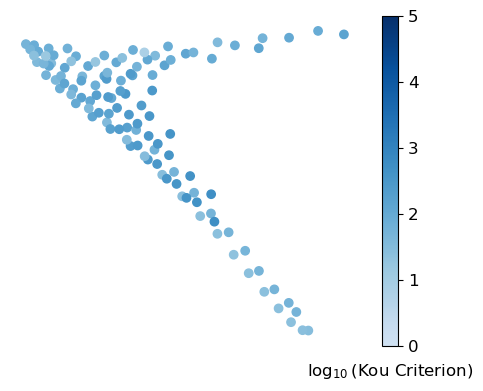

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_0_kou_log10_fixedrange.png


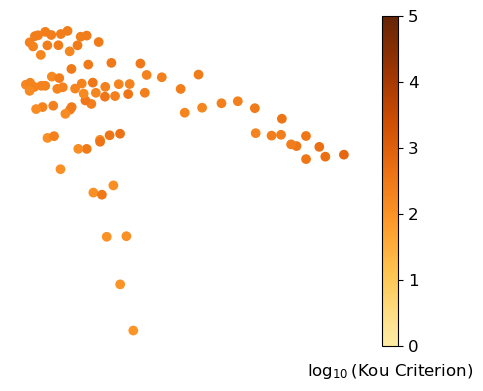

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_1_kou_log10_fixedrange.png


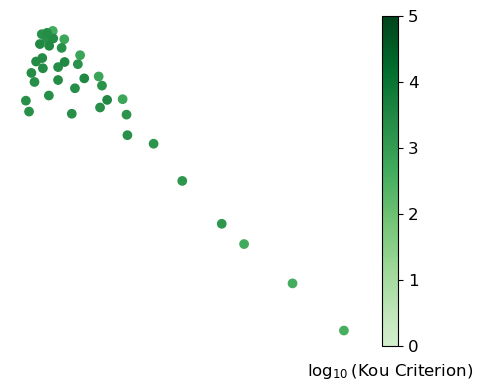

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_2_kou_log10_fixedrange.png


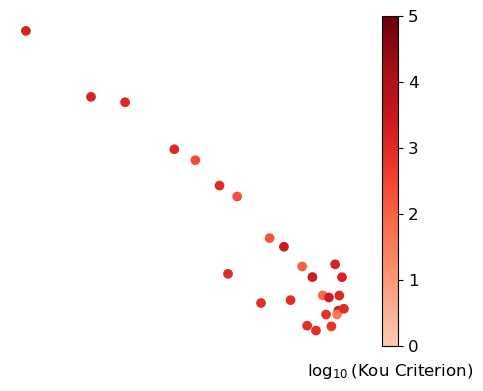

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_3_kou_log10_fixedrange.png


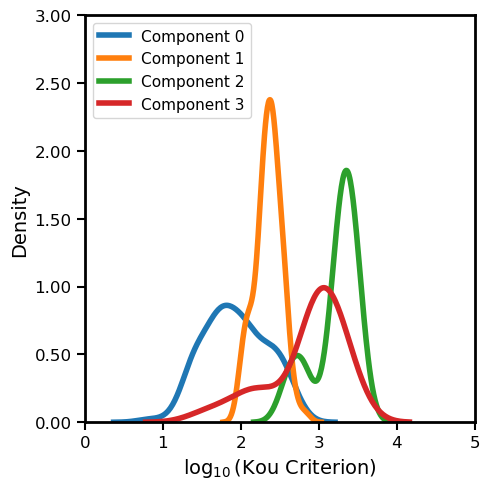

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /kde_kou_log10_fixedrange.png


In [16]:
PROP_KOU = "Kou Criteria"
N_COMPONENTS = 4
save_dir = os.getcwd()

# Hard-coded display ranges (log10 space)
KOU_LOG_VMIN, KOU_LOG_VMAX = 0.0, 5.0
KDE_YMIN, KDE_YMAX = 0.0, 3.0
KDE_YTICKS = np.arange(KDE_YMIN, KDE_YMAX + 0.001, 0.50)

component_colormaps = {0: plt.cm.Blues, 1: plt.cm.YlOrBr, 2: plt.cm.Greens, 3: plt.cm.Reds}

# UMAP plots per component, colored by log10(Kou Criterion)
for comp_idx, comp_nodes in enumerate(sorted_components[:N_COMPONENTS]):
    component_df = df[df["Node ID"].isin(list(comp_nodes))].copy()
    component_df[PROP_KOU] = pd.to_numeric(component_df[PROP_KOU], errors="coerce")
    component_df = component_df.dropna(subset=[PROP_KOU])
    component_df = component_df[component_df[PROP_KOU] > 0]

    if component_df.empty:
        print(f"No valid positive data for {PROP_KOU} in Component {comp_idx}")
        continue

    component_df["kou_log10"] = np.log10(component_df[PROP_KOU])

    base_cmap = component_colormaps.get(comp_idx, plt.cm.viridis)
    cmap = truncate_colormap(base_cmap, minval=0.2, maxval=1.0)

    norm = Normalize(vmin=KOU_LOG_VMIN, vmax=KOU_LOG_VMAX)
    ticks = np.arange(KOU_LOG_VMIN, KOU_LOG_VMAX + 0.001, 1.0)

    fig, ax = plt.subplots(figsize=(5, 4))
    sc = ax.scatter(component_df["umap0"], component_df["umap1"], c=component_df["kou_log10"], cmap=cmap, norm=norm)

    cbar = fig.colorbar(sc, ax=ax, ticks=ticks)
    cbar.ax.set_yticklabels([f"{int(t)}" for t in ticks])
    cbar.set_label("")
    cbar.ax.text(0.5, -0.05, r"$\log_{10}$(Kou Criterion)", transform=cbar.ax.transAxes,
                 ha="center", va="top", fontsize=12)
    cbar.ax.tick_params(labelsize=12)

    ax.axis("off")
    plt.tight_layout()
    plt.show()

    out_name = f"connected_component_{comp_idx}_kou_log10_fixedrange.png"
    out_path = os.path.join(save_dir, out_name)
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")

# KDE plot across components in log10(Kou Criterion)
plt.figure(figsize=(5, 5))

for comp_idx, comp_nodes in enumerate(sorted_components[:N_COMPONENTS]):
    component_df = df[df["Node ID"].isin(list(comp_nodes))].copy()
    component_df[PROP_KOU] = pd.to_numeric(component_df[PROP_KOU], errors="coerce")
    component_df = component_df.dropna(subset=[PROP_KOU])
    component_df = component_df[component_df[PROP_KOU] > 0]

    if component_df.empty:
        print(f"No valid data for {PROP_KOU} in Component {comp_idx}")
        continue

    log_vals = np.log10(component_df[PROP_KOU])
    sns.kdeplot(log_vals, linewidth=4, label=f"Component {comp_idx}")

plt.xlabel(r"$\log_{10}$(Kou Criterion)", fontsize=14)
plt.ylabel("Density", fontsize=14)

ax = plt.gca()
ax.set_xlim((KOU_LOG_VMIN, KOU_LOG_VMAX))
ax.set_ylim((KDE_YMIN, KDE_YMAX))

ax.set_xticks(np.arange(KOU_LOG_VMIN, KOU_LOG_VMAX + 0.001, 1.0))
ax.set_yticks(KDE_YTICKS)
ax.set_yticklabels([f"{t:.2f}" for t in KDE_YTICKS])

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(width=1.5, length=6)
plt.legend(loc="upper left", fontsize=11)

for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()

out_name = "kde_kou_log10_fixedrange.png"
out_path = os.path.join(save_dir, out_name)
plt.savefig(out_path, dpi=800, bbox_inches="tight", pad_inches=0.1)
plt.show()
print(f"Saved: {out_path}")

# Yield Strength

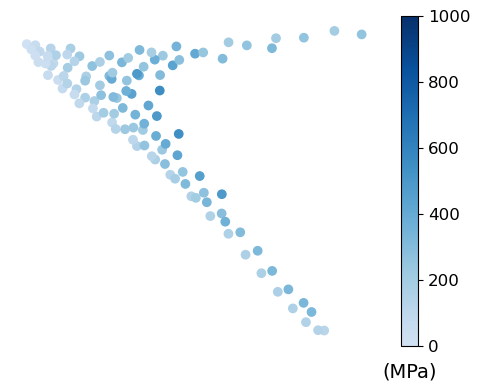

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_0_ys_fixedrange.png


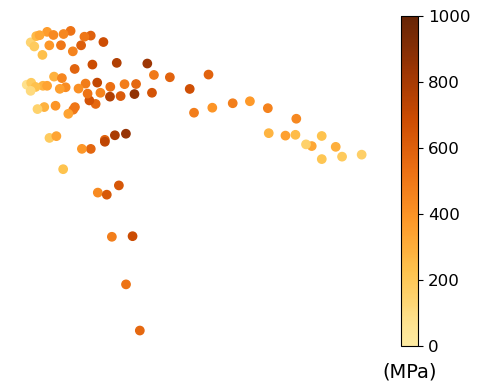

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_1_ys_fixedrange.png


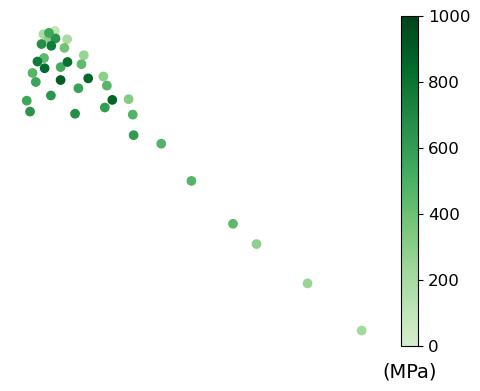

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_2_ys_fixedrange.png


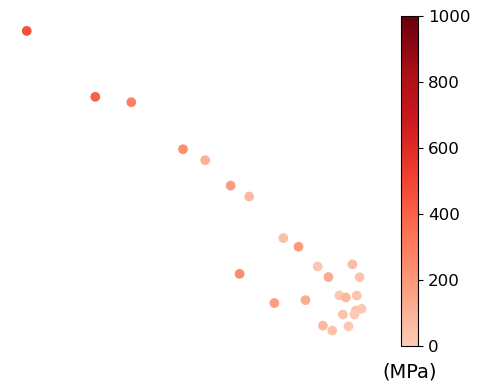

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_3_ys_fixedrange.png


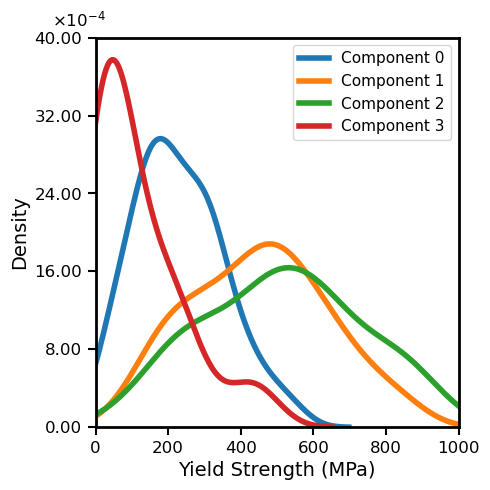

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /kde_yield_strength_fixedrange.png


In [17]:
PROP_YS = "YS 1000C PRIOR"
N_COMPONENTS = 4
save_dir = os.getcwd()

# Hard-coded display ranges
YS_XMIN, YS_XMAX = 0.0, 1000.0
YS_XTICKS = np.arange(YS_XMIN, YS_XMAX + 0.001, 200.0)

KDE_YMIN, KDE_YMAX = 0.00, 40.00
KDE_YTICKS = np.arange(KDE_YMIN, KDE_YMAX + 0.001, 8.00)

component_colormaps = {0: plt.cm.Blues, 1: plt.cm.YlOrBr, 2: plt.cm.Greens, 3: plt.cm.Reds}

# UMAP plots per component, colored by yield strength
for comp_idx, comp_nodes in enumerate(sorted_components[:N_COMPONENTS]):
    component_df = df[df["Node ID"].isin(list(comp_nodes))].copy()
    component_df[PROP_YS] = pd.to_numeric(component_df[PROP_YS], errors="coerce")
    component_df = component_df.dropna(subset=[PROP_YS])
    component_df = component_df[component_df[PROP_YS] >= 0]

    if component_df.empty:
        print(f"No valid data for {PROP_YS} in Component {comp_idx}")
        continue

    base_cmap = component_colormaps.get(comp_idx, plt.cm.viridis)
    cmap = truncate_colormap(base_cmap, minval=0.2, maxval=1.0)
    norm = Normalize(vmin=YS_XMIN, vmax=YS_XMAX)

    fig, ax = plt.subplots(figsize=(5, 4))
    sc = ax.scatter(component_df["umap0"], component_df["umap1"], c=component_df[PROP_YS], cmap=cmap, norm=norm)

    cbar = fig.colorbar(sc, ax=ax, ticks=YS_XTICKS)
    cbar.ax.set_yticklabels([f"{int(t)}" for t in YS_XTICKS])
    cbar.set_label("")
    cbar.ax.text(0.5, -0.05, "(MPa)", transform=cbar.ax.transAxes, ha="center", va="top", fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    ax.axis("off")
    plt.tight_layout()
    plt.show()

    out_name = f"connected_component_{comp_idx}_ys_fixedrange.png"
    out_path = os.path.join(save_dir, out_name)
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")

# KDE plot across components for yield strength (y-axis shown in ×10^-4)
plt.figure(figsize=(5, 5))

for comp_idx, comp_nodes in enumerate(sorted_components[:N_COMPONENTS]):
    component_df = df[df["Node ID"].isin(list(comp_nodes))].copy()
    component_df[PROP_YS] = pd.to_numeric(component_df[PROP_YS], errors="coerce")
    component_df = component_df.dropna(subset=[PROP_YS])
    component_df = component_df[component_df[PROP_YS] >= 0]

    if component_df.empty:
        print(f"No valid data for {PROP_YS} in Component {comp_idx}")
        continue

    sns.kdeplot(component_df[PROP_YS], linewidth=4, label=f"Component {comp_idx}")

plt.xlabel("Yield Strength (MPa)", fontsize=14)
plt.ylabel("Density", fontsize=14)

ax = plt.gca()
ax.set_xlim((YS_XMIN, YS_XMAX))
ax.set_xticks(YS_XTICKS)

ax.set_ylim((KDE_YMIN * 1e-4, KDE_YMAX * 1e-4))
ax.set_yticks(KDE_YTICKS * 1e-4)
ax.set_yticklabels([f"{t:.2f}" for t in KDE_YTICKS])

ax.text(-0.12, 1.02, r"$\times 10^{-4}$", transform=ax.transAxes, ha="left", va="bottom", fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(width=1.5, length=6)
plt.legend(loc="upper right", fontsize=11)

for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()

out_name = "kde_yield_strength_fixedrange.png"
out_path = os.path.join(save_dir, out_name)
plt.savefig(out_path, dpi=800, bbox_inches="tight", pad_inches=0.1)
plt.show()
print(f"Saved: {out_path}")

# Pugh Ratio

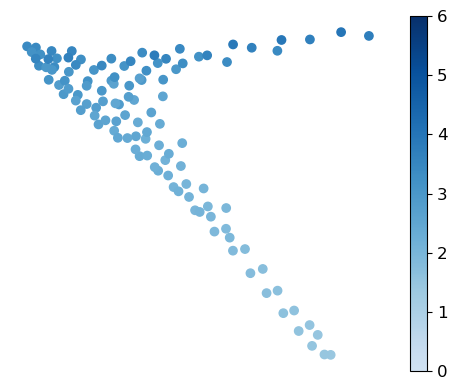

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_0_pugh_fixedrange.png


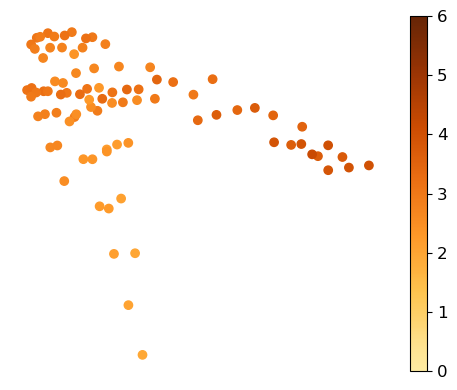

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_1_pugh_fixedrange.png


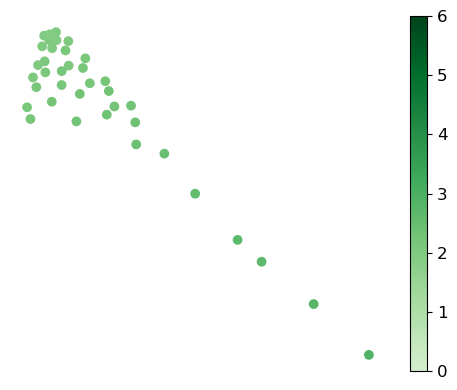

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_2_pugh_fixedrange.png


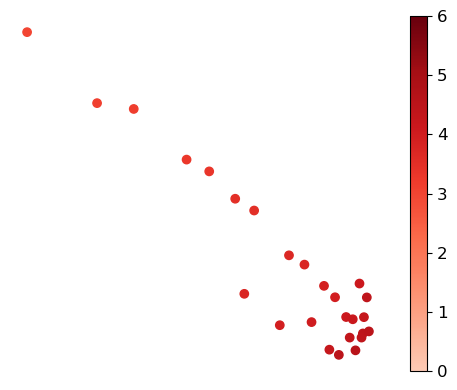

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /connected_component_3_pugh_fixedrange.png


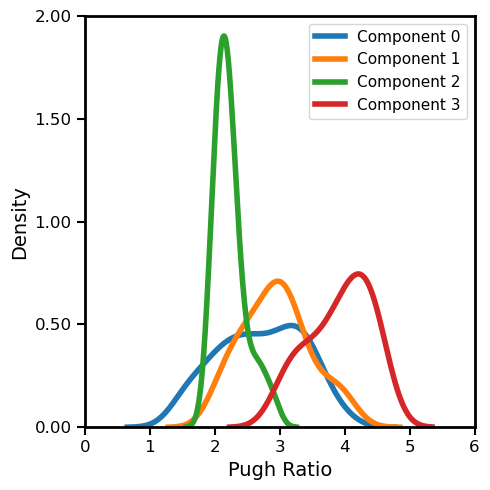

Saved: /Users/mikaylaobrist/Desktop/Zenodo Trial /kde_pugh_fixedrange.png


In [18]:
PROP_PUGH = "Pugh_Ratio_PRIOR"
N_COMPONENTS = 4
save_dir = os.getcwd()

# Hard-coded display ranges
PUGH_XMIN, PUGH_XMAX = 0.0, 6.0
PUGH_XTICKS = np.arange(PUGH_XMIN, PUGH_XMAX + 0.001, 1.0)

KDE_YMIN, KDE_YMAX = 0.00, 2.00
KDE_YTICKS = np.arange(KDE_YMIN, KDE_YMAX + 0.001, 0.50)

component_colormaps = {0: plt.cm.Blues, 1: plt.cm.YlOrBr, 2: plt.cm.Greens, 3: plt.cm.Reds}

# UMAP plots per component, colored by Pugh ratio
for comp_idx, comp_nodes in enumerate(sorted_components[:N_COMPONENTS]):
    component_df = df[df["Node ID"].isin(list(comp_nodes))].copy()
    component_df[PROP_PUGH] = pd.to_numeric(component_df[PROP_PUGH], errors="coerce")
    component_df = component_df.dropna(subset=[PROP_PUGH])

    if component_df.empty:
        print(f"No valid data for {PROP_PUGH} in Component {comp_idx}")
        continue

    base_cmap = component_colormaps.get(comp_idx, plt.cm.viridis)
    cmap = truncate_colormap(base_cmap, minval=0.2, maxval=1.0)
    norm = Normalize(vmin=PUGH_XMIN, vmax=PUGH_XMAX)

    fig, ax = plt.subplots(figsize=(5, 4))
    sc = ax.scatter(component_df["umap0"], component_df["umap1"], c=component_df[PROP_PUGH], cmap=cmap, norm=norm)

    cbar = fig.colorbar(sc, ax=ax, ticks=PUGH_XTICKS)
    cbar.ax.set_yticklabels([f"{int(t)}" for t in PUGH_XTICKS])
    cbar.set_label("")
    cbar.ax.tick_params(labelsize=12)

    ax.axis("off")
    plt.tight_layout()
    plt.show()

    out_name = f"connected_component_{comp_idx}_pugh_fixedrange.png"
    out_path = os.path.join(save_dir, out_name)
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")

# KDE plot across components for Pugh ratio
plt.figure(figsize=(5, 5))

for comp_idx, comp_nodes in enumerate(sorted_components[:N_COMPONENTS]):
    component_df = df[df["Node ID"].isin(list(comp_nodes))].copy()
    component_df[PROP_PUGH] = pd.to_numeric(component_df[PROP_PUGH], errors="coerce")
    component_df = component_df.dropna(subset=[PROP_PUGH])

    if component_df.empty:
        print(f"No valid data for {PROP_PUGH} in Component {comp_idx}")
        continue

    sns.kdeplot(component_df[PROP_PUGH], linewidth=4, label=f"Component {comp_idx}")

plt.xlabel("Pugh Ratio", fontsize=14)
plt.ylabel("Density", fontsize=14)

ax = plt.gca()
ax.set_xlim((PUGH_XMIN, PUGH_XMAX))
ax.set_ylim((KDE_YMIN, KDE_YMAX))
ax.set_xticks(PUGH_XTICKS)
ax.set_yticks(KDE_YTICKS)
ax.set_yticklabels([f"{t:.2f}" for t in KDE_YTICKS])

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(width=1.5, length=6)
plt.legend(loc="upper right", fontsize=11)

for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()

out_name = "kde_pugh_fixedrange.png"
out_path = os.path.join(save_dir, out_name)
plt.savefig(out_path, dpi=800, bbox_inches="tight", pad_inches=0.1)
plt.show()
print(f"Saved: {out_path}")

# Radar Plot

In [19]:
# Log10 summary stats for one property across components 0–3
prop_col = "Kou Criteria"

prop_name_map = globals().get("prop_name_mapping", {})
label = prop_name_map.get(prop_col, prop_col)
print(f"\nProperty (log10): {label}")

for i, component in enumerate(sorted_components[:4]):
    comp_df = df[df["Node ID"].isin(list(component))].copy()
    comp_df[prop_col] = pd.to_numeric(comp_df[prop_col], errors="coerce")
    vals = comp_df[prop_col].dropna()

    logs = np.log10(vals[vals > 0])
    n = logs.size

    if n:
        lmean = logs.mean()
        lmin = logs.min()
        lmax = logs.max()
        lrange = lmax - lmin
        lvar = logs.var(ddof=1) if n >= 2 else float("nan")
        lsd = logs.std(ddof=1) if n >= 2 else float("nan")
    else:
        lmean = lmin = lmax = lrange = lvar = lsd = float("nan")
        n = 0

    print(f"  Connected Component {i} (n={n})  "
        f"avg: \033[1m{lmean:.4g}\033[0m  "
        f"min: \033[1m{lmin:.4g}\033[0m  "
        f"max: \033[1m{lmax:.4g}\033[0m  "
        f"range: \033[1m{lrange:.4g}\033[0m  "
        f"var: \033[1m{lvar:.4g}\033[0m  "
        f"sd: \033[1m{lsd:.4g}\033[0m")


Property (log10): Kou Criteria
  Connected Component 0 (n=117)  avg: 1.934  min: 0.8358  max: 2.742  range: 1.906  var: 0.1628  sd: 0.4035
  Connected Component 1 (n=86)  avg: 2.354  min: 1.98  max: 2.824  range: 0.8449  var: 0.02846  sd: 0.1687
  Connected Component 2 (n=38)  avg: 3.219  min: 2.572  max: 3.508  range: 0.9364  var: 0.0788  sd: 0.2807
  Connected Component 3 (n=26)  avg: 2.846  min: 1.541  max: 3.399  range: 1.858  var: 0.2378  sd: 0.4876


In [20]:
# Compute component-wise stats for selected non-proprietary properties and write to Excel
prop_specs = [
    ("1000 Min Creep NH [1/s]", "log10",  "Creep (log10)"),
    ("Pugh_Ratio_PRIOR",        "linear", "Pugh"),
    ("YS 1000C PRIOR",          "linear", "YS"),
    ("Kou Criteria",            "log10",  "Kou (log10)"),
]

prop_name_map = globals().get("prop_name_mapping", {})

def _stats_for(series, space):
    vals = pd.to_numeric(series, errors="coerce").dropna()
    if space == "log10":
        vals = vals[vals > 0]
        vals = np.log10(vals)

    n = int(vals.size)
    if n == 0:
        return dict(n=0, mean=np.nan, min=np.nan, max=np.nan, range=np.nan, variance=np.nan, std_dev=np.nan)

    mean_val = vals.mean()
    min_val = vals.min()
    max_val = vals.max()

    return {
        "n": n,
        "mean": mean_val,
        "min": min_val,
        "max": max_val,
        "range": max_val - min_val,
        "variance": (vals.var(ddof=1) if n >= 2 else np.nan),
        "std_dev": (vals.std(ddof=1) if n >= 2 else np.nan),
    }

all_rows = []
per_prop_frames = {}

for prop_col, space, short_name in prop_specs:
    rows = []
    for i, component in enumerate(sorted_components[:4]):
        comp_df = df[df["Node ID"].isin(component)]
        stats = _stats_for(comp_df[prop_col], space)

        row = {"property": prop_name_map.get(prop_col, prop_col), "prop_col": prop_col, 
               "space": space, "component": i, **stats}
        rows.append(row)
        all_rows.append(row)

    per_prop_frames[short_name] = pd.DataFrame(rows)

stats_df = pd.DataFrame(all_rows)

with pd.ExcelWriter("component_stats.xlsx", engine="openpyxl") as writer:
    stats_df.to_excel(writer, sheet_name="All_Tidy", index=False)
    for sheet_name, frame in per_prop_frames.items():
        frame.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Wrote component_stats.xlsx with sheets: All_Tidy + one per property.")

Wrote component_stats.xlsx with sheets: All_Tidy + one per property.


In [21]:
# Build normalized radar “boxplot” figures per component and stitch them
xlsx_path = "component_stats.xlsx"
sheet_name = "All_Tidy"

prop_order = [
    ("Kou Criteria",                "Kou"),
    ("1000 Min Creep NH [1/s]",     "Creep"),
    ("Pugh_Ratio_PRIOR",            "Pugh"),
    ("YS 1000C PRIOR",              "YS"),
]

components = [0, 1, 2, 3]
comp_colors = ["blue", "orange", "green", "red"]

stats = pd.read_excel(xlsx_path, sheet_name=sheet_name)

def pick_col(df_in, options):
    for c in options:
        if c in df_in.columns:
            return c
    raise KeyError(f"None of {options} found in columns={list(df_in.columns)}")

col_property = pick_col(stats, ["property", "prop_col", "Property", "Prop"])
col_component = pick_col(stats, ["component", "Component"])
col_mean = pick_col(stats, ["mean", "Mean", "avg", "Avg"])
col_min = pick_col(stats, ["min", "Min"])
col_max = pick_col(stats, ["max", "Max"])
col_sd = pick_col(stats, ["std_dev", "sd", "StdDev", "std"])

def first_numeric(rows_subset, comp, col):
    s = rows_subset.loc[rows_subset[col_component] == comp, col]
    s = pd.to_numeric(s, errors="coerce").dropna()
    return float(s.iloc[0]) if not s.empty else np.nan

means_by_prop, mins_by_prop, maxs_by_prop, sds_by_prop = {}, {}, {}, {}

for prop_key, _short in prop_order:
    rows = stats[stats[col_property] == prop_key]
    means_by_prop[prop_key] = np.array([first_numeric(rows, c, col_mean) for c in components], float)
    mins_by_prop[prop_key] = np.array([first_numeric(rows, c, col_min) for c in components], float)
    maxs_by_prop[prop_key] = np.array([first_numeric(rows, c, col_max) for c in components], float)
    sds_by_prop[prop_key] = np.array([first_numeric(rows, c, col_sd) for c in components], float)

global_min, global_max = {}, {}
for prop_key, _ in prop_order:
    mn = np.nanmin(mins_by_prop[prop_key]) if np.isfinite(mins_by_prop[prop_key]).any() else np.nan
    mx = np.nanmax(maxs_by_prop[prop_key]) if np.isfinite(maxs_by_prop[prop_key]).any() else np.nan
    global_min[prop_key] = mn
    global_max[prop_key] = mx

def norm_vals(x, prop_key):
    a, b = global_min[prop_key], global_max[prop_key]
    if not np.isfinite(a) or not np.isfinite(b) or np.isclose(a, b):
        return np.full_like(np.array(x, float), 0.5)
    return np.clip((np.array(x, float) - a) / (b - a), 0.0, 1.0)

rows_norm = []
labels = [short for _p, short in prop_order]

for prop_key, short in prop_order:
    m, mn, mx, sd = means_by_prop[prop_key], mins_by_prop[prop_key], maxs_by_prop[prop_key], sds_by_prop[prop_key]
    for comp in components:
        mean, minv, maxv, sdev = m[comp], mn[comp], mx[comp], sd[comp]
        lo_sd = mean - sdev if np.isfinite(mean) and np.isfinite(sdev) else np.nan
        hi_sd = mean + sdev if np.isfinite(mean) and np.isfinite(sdev) else np.nan

        rows_norm.append({
            "component": comp,
            "property": prop_key,
            "label": short,
            "mean_norm": float(norm_vals(mean, prop_key)),
            "min_norm": float(norm_vals(minv, prop_key)),
            "max_norm": float(norm_vals(maxv, prop_key)),
            "sd_low_norm": float(norm_vals(lo_sd, prop_key)),
            "sd_high_norm": float(norm_vals(hi_sd, prop_key)),
        })

norm_df = pd.DataFrame(rows_norm)

print("\n=== Normalized values used for radar boxplots (per component × property) ===")
print(norm_df.sort_values(["component", "property"]).round(6).to_string(index=False))

num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles_closed = np.r_[angles, angles[:1]]
bar_width = (2 * np.pi / num_vars) * 0.18

out_files = []
for comp_idx in components:
    dfc = norm_df[norm_df["component"] == comp_idx]
    order = [dfc[dfc["label"] == lab] for lab in labels]

    r_min = np.array([x["min_norm"].iloc[0] if len(x) else np.nan for x in order], float)
    r_max = np.array([x["max_norm"].iloc[0] if len(x) else np.nan for x in order], float)
    r_mean = np.array([x["mean_norm"].iloc[0] if len(x) else np.nan for x in order], float)
    r_lo = np.array([x["sd_low_norm"].iloc[0] if len(x) else np.nan for x in order], float)
    r_hi = np.array([x["sd_high_norm"].iloc[0] if len(x) else np.nan for x in order], float)

    r_lo_clip = np.maximum(0, np.minimum(1, np.maximum(r_lo, r_min)))
    r_hi_clip = np.minimum(1, np.maximum(0, np.minimum(r_hi, r_max)))

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.spines["polar"].set_linewidth(2.5)

    for th, lo, hi in zip(angles, r_min, r_max):
        if np.isfinite(lo) and np.isfinite(hi):
            ax.plot([th, th], [lo, hi], color="black", linewidth=1.2, alpha=0.8, zorder=2)

    for th, lo, hi in zip(angles, r_lo_clip, r_hi_clip):
        if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
            ax.bar(th, height=hi - lo, bottom=lo, width=bar_width, align="center",
                   edgecolor="none", alpha=0.25, color=comp_colors[comp_idx], zorder=1)

    r_mean_closed = np.r_[r_mean, r_mean[:1]]
    ax.plot(angles_closed, r_mean_closed, color=comp_colors[comp_idx], linewidth=2.0, zorder=3)
    ax.scatter(angles, r_mean, s=50, color=comp_colors[comp_idx], zorder=4)

    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.grid(False)
    ax.set_yticklabels([])

    ax.set_xticks(angles)
    tick_labels = ax.set_xticklabels(labels, fontsize=18, fontweight="bold")
    for lbl in tick_labels:
        lbl.set_path_effects([path_effects.Stroke(linewidth=3, foreground="white"), 
                              path_effects.Normal()])

    ax.text(0.5, 0.5, str(comp_idx), transform=ax.transAxes, fontsize=40, ha="center", 
            va="center", color="black")

    ax.set_title(
        "Radar boxplot (whisker=min–max, band=mean±SD)\nPer-property min–max normalization across all components",
        va="bottom", fontsize=11)

    ax.xaxis.set_tick_params(pad=20)
    plt.tight_layout(pad=3.0)

    out_name = f"component_{comp_idx}_radar_boxplot.png"
    plt.savefig(out_name, dpi=300, bbox_inches="tight")
    plt.close(fig)
    out_files.append(out_name)
    print(f"Saved {out_name}")

imgs = [Image.open(p).convert("RGBA") for p in out_files]
w = min(im.size[0] for im in imgs)
h = min(im.size[1] for im in imgs)
imgs = [im.resize((w, h)) for im in imgs]

padding = 70
total_w = w * len(imgs) + padding * (len(imgs) - 1)
canvas = Image.new("RGBA", (total_w, h), (255, 255, 255, 255))

for i, im in enumerate(imgs):
    canvas.paste(im, (i * (w + padding), 0), im)

canvas.convert("RGB").save("snowflake_combined_boxplots.png")
canvas.show()
plt.show()
print("Saved snowflake_combined_boxplots.png")


=== Normalized values used for radar boxplots (per component × property) ===
 component                property label  mean_norm  min_norm  max_norm  sd_low_norm  sd_high_norm
         0 1000 Min Creep NH [1/s] Creep   0.655145  0.000000  0.992599     0.416674      0.893616
         0            Kou Criteria   Kou   0.411125  0.000000  0.713234     0.260152      0.562097
         0        Pugh_Ratio_PRIOR  Pugh   0.406869  0.000000  0.818202     0.200157      0.613580
         0          YS 1000C PRIOR    YS   0.255412  0.005843  0.616834     0.119095      0.391730
         1 1000 Min Creep NH [1/s] Creep   0.611794  0.170641  0.985001     0.432592      0.790996
         1            Kou Criteria   Kou   0.568186  0.427999  0.744138     0.505062      0.631311
         1        Pugh_Ratio_PRIOR  Pugh   0.481262  0.165842  0.873866     0.314191      0.648333
         1          YS 1000C PRIOR    YS   0.499884  0.085164  0.955485     0.290231      0.709538
         2 1000 Min Creep NH [1